In [ ]:
from google.colab import drive
drive.mount('/content/drive')
# set these paths:
DRIVE_FOLDER = "/content/drive/MyDrive/Image Dataset"   # change to the folder that contains classes
!ls -lah "$DRIVE_FOLDER"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
total 26M
-rw------- 1 root root  57K Dec  8 09:57  english.csv
-rw------- 1 root root 8.2K Feb 24  2021  img001-001.png
-rw------- 1 root root 7.7K Feb 24  2021  img001-002.png
-rw------- 1 root root 9.4K Feb 24  2021  img001-003.png
-rw------- 1 root root 7.0K Feb 24  2021  img001-004.png
-rw------- 1 root root 7.3K Feb 24  2021  img001-005.png
-rw------- 1 root root 6.3K Feb 24  2021  img001-006.png
-rw------- 1 root root 6.0K Feb 24  2021  img001-007.png
-rw------- 1 root root 6.9K Feb 24  2021  img001-008.png
-rw------- 1 root root 9.5K Feb 24  2021  img001-009.png
-rw------- 1 root root 6.8K Feb 24  2021  img001-010.png
-rw------- 1 root root 6.4K Feb 24  2021  img001-011.png
-rw------- 1 root root 8.2K Feb 24  2021  img001-012.png
-rw------- 1 root root 6.4K Feb 24  2021  img001-013.png
-rw------- 1 root root 8.8K Feb 24  2021  img001-014.png
-rw------

In [ ]:
%%bash
pip3 install -q tensorflow pillow scikit-learn


In [ ]:
import os, random, shutil
from PIL import Image
import pandas as pd
from sklearn.model_selection import train_test_split

SRC_BASE_DIR = DRIVE_FOLDER   # Original folder with all images
DST_BASE_DIR = "/content/processed_dataset"
IMG_SIZE = (28,28)

# Clear destination directory if it exists to avoid conflicts
if os.path.exists(DST_BASE_DIR):
    shutil.rmtree(DST_BASE_DIR)
os.makedirs(DST_BASE_DIR, exist_ok=True)

# Load metadata (assuming 'metadata' DataFrame is already available from previous cells)
# If not, it would need to be reloaded here or passed as an argument.
# For this fix, we assume 'metadata' is already in the global scope.
metadata = pd.read_csv('https://drive.google.com/uc?export=download&id=1w4j4nEyeFfPsNsUNJ0cBnbzzuEgJ_qac') # uncomment if metadata not available

# Prepare data for splitting
all_image_paths = [os.path.join(SRC_BASE_DIR, row['image']) for index, row in metadata.iterrows()]
all_labels = metadata['label'].astype(str).tolist() # Ensure labels are strings for directory names

# Split data (using file paths and labels)
X_temp, X_test, y_temp, y_test = train_test_split(all_image_paths, all_labels, test_size=0.2, random_state=42, stratify=all_labels)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp) # 0.25 of 0.8 is 0.2 (val_ratio = 0.2)

splits = {
    "train": (X_train, y_train),
    "val": (X_val, y_val),
    "test": (X_test, y_test)
}

print(f"Total images: {len(all_image_paths)}")
print(f"Train images: {len(X_train)}")
print(f"Validation images: {len(X_val)}")
print(f"Test images: {len(X_test)}")

# Function to process and save images
def save_images_to_split(image_paths, labels, split_name):
    for i in range(len(image_paths)):
        src_path = image_paths[i]
        label = labels[i]
        fname = os.path.basename(src_path)

        out_class_dir = os.path.join(DST_BASE_DIR, split_name, label)
        os.makedirs(out_class_dir, exist_ok=True) # Create class directory

        dst_path = os.path.join(out_class_dir, fname)
        try:
            img = Image.open(src_path).convert("L")
            # Changed Image.ANTIALIAS to Image.LANCZOS
            img = img.resize(IMG_SIZE, Image.LANCZOS)
            img.save(dst_path)
        except Exception as e:
            print("skip", src_path, e)

# Process and save for each split
for split_name, (paths, lbls) in splits.items():
    print(f"Processing {split_name} split...")
    save_images_to_split(paths, lbls, split_name)

print("Processed to", DST_BASE_DIR)
!du -sh "$DST_BASE_DIR" || true

Total images: 3410
Train images: 2046
Validation images: 682
Test images: 682
Processing train split...
Processing val split...
Processing test split...
Processed to /content/processed_dataset
15M	/content/processed_dataset


            image label
0  img001-001.png     0
1  img001-002.png     0
2  img001-003.png     0
3  img001-004.png     0
4  img001-005.png     0
Number of classes: 62


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 174ms/step - accuracy: 0.0196 - loss: 4.1330 - val_accuracy: 0.0275 - val_loss: 4.1235
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0178 - loss: 4.1124 - val_accuracy: 0.0330 - val_loss: 4.1008
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0430 - loss: 4.0702 - val_accuracy: 0.0604 - val_loss: 4.0183
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0634 - loss: 3.9581 - val_accuracy: 0.1209 - val_loss: 3.8111
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0900 - loss: 3.7403 - val_accuracy: 0.1612 - val_loss: 3.5246
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1248 - loss: 3.4639 - val_accuracy: 0.2125 - val_loss: 3.2453
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1978 - loss: 3.1957 - val_accuracy: 0.2234 - val_loss: 3.0261
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2383 - loss: 3.0242 - val_accuracy: 0.2766 - val_los

Test accuracy: 0.4091


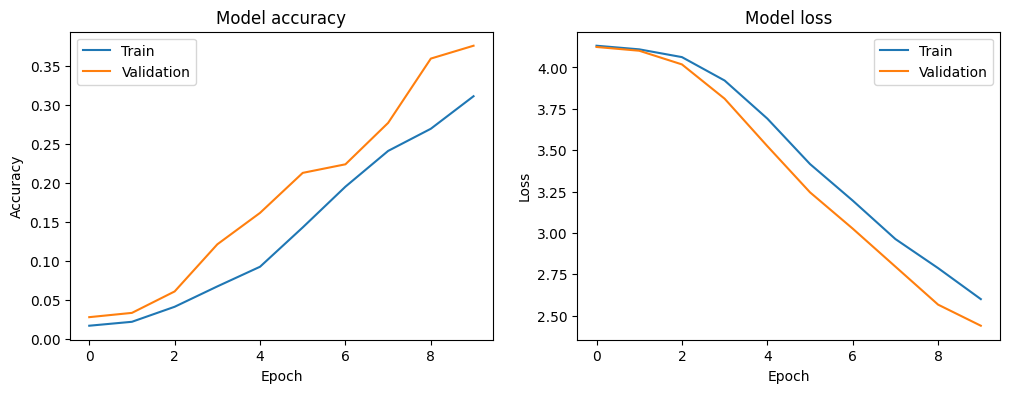

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import pickle

# Define paths
# Corrected metadata_path for direct download from Google Drive
metadata_path = 'https://drive.google.com/uc?export=download&id=1w4j4nEyeFfPsNsUNJ0cBnbzzuEgJ_qac'
base_dir = r'/content/drive/MyDrive/Image Dataset'  # Use raw string to handle backslashes

# Load metadata
metadata = pd.read_csv(metadata_path)
print(metadata.head())

# Function to load and preprocess images
def load_and_preprocess_images(metadata, base_dir):
    images = []
    labels = []
    for index, row in metadata.iterrows():
        filename = row['image']
        label = row['label']
        img_path = os.path.join(base_dir, filename)
        try:
            img = load_img(img_path, color_mode='grayscale', target_size=(28, 28))
            img_array = img_to_array(img) / 255.0
            images.append(img_array)
            labels.append(label)
        except FileNotFoundError:
            print(f"Image not found: {img_path}")
            continue
    return np.array(images), np.array(labels)

# Load and preprocess
X, y = load_and_preprocess_images(metadata, base_dir)
X = X.reshape((X.shape[0], 28, 28, 1))

# Encode labels
lb = LabelBinarizer()
y = lb.fit_transform(y)
num_classes = len(lb.classes_)
print(f"Number of classes: {num_classes}")  # Should be 62

# Save label binarizer
with open('label_binarizer.pkl', 'wb') as f:
    pickle.dump(lb, f)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define model
model = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

# Compile and train
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, validation_split=0.2, epochs=10, batch_size=128)

# Evaluate
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f'Test accuracy: {test_accuracy:.4f}')

# Save model
model.save('handwritten_character_recognition_model.h5')

# Optional: Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [ ]:
import os, pandas as pd

# if you have a dataframe mapping image->label (like you printed)
df = metadata   # Use the existing metadata DataFrame
print(df['label'].value_counts().sort_values(ascending=False).head(20))

label
0    55
1    55
2    55
3    55
4    55
5    55
6    55
7    55
8    55
9    55
A    55
B    55
C    55
D    55
E    55
F    55
G    55
H    55
I    55
J    55
Name: count, dtype: int64


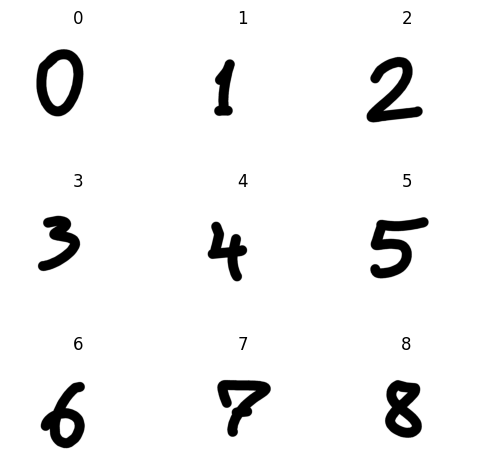

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
samples = df.groupby('label').first().reset_index()[:9]
plt.figure(figsize=(6,6))
for i,row in enumerate(samples.itertuples()):
    # Corrected path to use base_dir and row.image
    img = Image.open(os.path.join(base_dir, row.image)).convert("L")
    plt.subplot(3,3,i+1); plt.imshow(img, cmap='gray'); plt.title(row.label); plt.axis('off')
plt.show()

In [ ]:
# improved_train_small_cnn.py
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np, json, os
from sklearn.utils.class_weight import compute_class_weight

DATA_DIR = "processed_dataset"   # same 28x28 grayscale structure
BATCH = 128
IMG_SIZE = (28,28)

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.12,
    height_shift_range=0.12,
    zoom_range=0.12,
    shear_range=0.05
).flow_from_directory(DATA_DIR+"/train", target_size=IMG_SIZE, color_mode="grayscale", batch_size=BATCH, class_mode="categorical", shuffle=True)

val_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(DATA_DIR+"/val", target_size=IMG_SIZE, color_mode="grayscale", batch_size=BATCH, class_mode="categorical")

num_classes = train_gen.num_classes
print("num_classes:", num_classes)

inp = layers.Input(shape=(28,28,1))
x = layers.Conv2D(32,3,padding='same',activation='relu')(inp)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(32,3,padding='same',activation='relu')(x)
x = layers.MaxPooling2D()(x)
x = layers.Dropout(0.2)(x)

x = layers.Conv2D(64,3,padding='same',activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(64,3,padding='same',activation='relu')(x)
x = layers.MaxPooling2D()(x)
x = layers.Dropout(0.25)(x)

x = layers.Conv2D(128,3,padding='same',activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)
x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.5)(x)
out = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs=inp, outputs=out)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss='categorical_crossentropy', metrics=['accuracy'])

# compute class weights
y = train_gen.classes  # array of labels per sample
class_weights = dict(enumerate(compute_class_weight('balanced', classes=np.unique(y), y=y)))
print("class_weights sample:", list(class_weights.items())[:5])

cb = [
    callbacks.ModelCheckpoint("best_improved.h5", save_best_only=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
    callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
]

history = model.fit(train_gen, validation_data=val_gen, epochs=60, callbacks=cb, class_weight=class_weights)
model.save("handwritten_character_recognition_model_improved.h5")


Found 2046 images belonging to 62 classes.
Found 682 images belonging to 62 classes.
num_classes: 62
class_weights sample: [(0, np.float64(1.0)), (1, np.float64(1.0)), (2, np.float64(1.0)), (3, np.float64(1.0)), (4, np.float64(1.0))]
Epoch 1/60


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - accuracy: 0.0120 - loss: 5.4282

16/16 ━━━━━━━━━━━━━━━━━━━━ 17s 620ms/step - accuracy: 0.0121 - loss: 5.3845 - val_accuracy: 0.0161 - val_loss: 4.2112 - learning_rate: 0.0010
Epoch 2/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.0210 - loss: 4.1666 - val_accuracy: 0.0205 - val_loss: 4.5546 - learning_rate: 0.0010
Epoch 3/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.0237 - loss: 4.1682 - val_accuracy: 0.0161 - val_loss: 5.0739 - learning_rate: 0.0010
Epoch 4/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.0190 - loss: 4.1669 - val_accuracy: 0.0161 - val_loss: 5.6310 - learning_rate: 0.0010
Epoch 5/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - accuracy: 0.0196 - loss: 4.1726 - val_accuracy: 0.0161 - val_loss: 6.1171 - learning_rate: 5.0000e-04
Epoch 6/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.0160 - loss: 4.1666 - val_accuracy: 0.0161 - val_loss: 6.5601 - learning_rate: 5.0000e-04
Epoch 7/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.0188 - loss: 4.1679 - val_acc

Found 2046 images belonging to 62 classes.
class_indices: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9, 'A': 10, 'B': 11, 'C': 12, 'D': 13, 'E': 14, 'F': 15, 'G': 16, 'H': 17, 'I': 18, 'J': 19, 'K': 20, 'L': 21, 'M': 22, 'N': 23, 'O': 24, 'P': 25, 'Q': 26, 'R': 27, 'S': 28, 'T': 29, 'U': 30, 'V': 31, 'W': 32, 'X': 33, 'Y': 34, 'Z': 35, 'a': 36, 'b': 37, 'c': 38, 'd': 39, 'e': 40, 'f': 41, 'g': 42, 'h': 43, 'i': 44, 'j': 45, 'k': 46, 'l': 47, 'm': 48, 'n': 49, 'o': 50, 'p': 51, 'q': 52, 'r': 53, 's': 54, 't': 55, 'u': 56, 'v': 57, 'w': 58, 'x': 59, 'y': 60, 'z': 61}
num_classes: 62
x_batch shape, dtype, min/max: (32, 28, 28, 1) float32 0.0 1.0
y_batch shape: (32, 62)


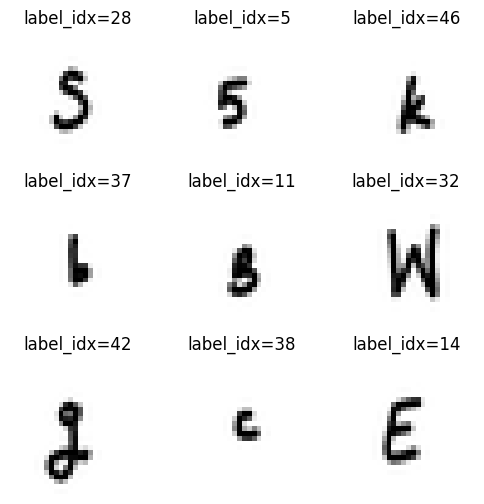

In [ ]:
# Run where you do training (Colab / local)
import numpy as np, matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

DATA_DIR = "processed_dataset"   # or your train path
IMG_SIZE=(28,28)
BATCH=32

gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    DATA_DIR+"/train", target_size=IMG_SIZE, color_mode="grayscale",
    batch_size=BATCH, class_mode="categorical", shuffle=True)

print("class_indices:", gen.class_indices)
print("num_classes:", gen.num_classes)
x_batch, y_batch = next(gen)   # one batch
print("x_batch shape, dtype, min/max:", x_batch.shape, x_batch.dtype, x_batch.min(), x_batch.max())
print("y_batch shape:", y_batch.shape)
# show first 9 images with their one-hot label index
fig,axs = plt.subplots(3,3,figsize=(6,6))
for i in range(9):
    axs[i//3,i%3].imshow(x_batch[i].squeeze(), cmap='gray')
    axs[i//3,i%3].set_title("label_idx="+str(y_batch[i].argmax()))
    axs[i//3,i%3].axis('off')
plt.show()


In [ ]:
import os, random
from PIL import Image

DRIVE_FOLDER = "/content/drive/MyDrive/Image Dataset" # Added definition for DRIVE_FOLDER
SRC = DRIVE_FOLDER  # change if different. Expect structure: <class_name>/*.png OR folder with 'train','val','test'
OUT = "/content/processed_dataset"
IMG_SIZE = (28,28)
os.makedirs(OUT, exist_ok=True)

# If your Drive folder already has train/val/test subfolders, copy them to processed_dataset
if any(x in os.listdir(DRIVE_FOLDER) for x in ["train","val","test"]):
    import shutil
    shutil.copytree(os.path.join(DRIVE_FOLDER,"train"), os.path.join(OUT,"train"), dirs_exist_ok=True)
    shutil.copytree(os.path.join(DRIVE_FOLDER,"val"), os.path.join(OUT,"val"), dirs_exist_ok=True)
    shutil.copytree(os.path.join(DRIVE_FOLDER,"test"), os.path.join(OUT,"test"), dirs_exist_ok=True)
    print("Copied existing train/val/test into", OUT)
else:
    # assume SRC contains per-class folders -> split into train/val/test (80/10/10)
    splits = {"train":0.8,"val":0.1,"test":0.1}
    for split in splits:
        os.makedirs(os.path.join(OUT, split), exist_ok=True)
    random.seed(42)
    for cls in sorted([d for d in os.listdir(SRC) if os.path.isdir(os.path.join(SRC,d))]):
        files = [f for f in os.listdir(os.path.join(SRC,cls)) if f.lower().endswith((".png",".jpg",".jpeg"))]
        random.shuffle(files)
        n = len(files)
        n_train = int(n * splits["train"])
        n_val = int(n * splits["val"])
        sets = {
            "train": files[:n_train],
            "val": files[n_train:n_train+n_val],
            "test": files[n_train+n_val:]
        }
        for split, flist in sets.items():
            target_dir = os.path.join(OUT, split, cls)
            os.makedirs(target_dir, exist_ok=True)
            for fname in flist:
                srcp = os.path.join(SRC, cls, fname)
                dstp = os.path.join(target_dir, fname)
                try:
                    img = Image.open(srcp).convert("L").resize(IMG_SIZE, Image.LANCZOS)
                    img.save(dstp)
                except Exception as e:
                    print("skip", srcp, e)
    print("Created processed dataset at", OUT)

# quick check
for s in ["train","val","test"]:
    cnt = sum(len(files) for _,_,files in os.walk(os.path.join(OUT,s)))
    print(f"{s}: {cnt} files")

Created processed dataset at /content/processed_dataset
train: 2046 files
val: 682 files
test: 682 files


In [ ]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [ ]:
# Cell 5 — overfit sanity test
import numpy as np, tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

DATA_DIR = "/content/processed_dataset"
IMG = (28,28)
BATCH = 32

gen = ImageDataGenerator(rescale=1./255).flow_from_directory(DATA_DIR + "/train", target_size=IMG, color_mode="grayscale", batch_size=BATCH, class_mode="categorical", shuffle=True)
x_batch, y_batch = next(gen)
print("class_indices:", gen.class_indices)
print("x_batch shape, dtype, min/max:", x_batch.shape, x_batch.dtype, x_batch.min(), x_batch.max())
print("y_batch shape:", y_batch.shape)
X_small, Y_small = x_batch[:16], y_batch[:16]

model = models.Sequential([
    layers.Input(shape=(28,28,1)),
    layers.Conv2D(16,3,activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(gen.num_classes, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
hist = model.fit(X_small, Y_small, epochs=100, verbose=2)
print("Final small overfit acc:", hist.history['accuracy'][-1])


Found 2046 images belonging to 62 classes.
class_indices: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9, 'A': 10, 'B': 11, 'C': 12, 'D': 13, 'E': 14, 'F': 15, 'G': 16, 'H': 17, 'I': 18, 'J': 19, 'K': 20, 'L': 21, 'M': 22, 'N': 23, 'O': 24, 'P': 25, 'Q': 26, 'R': 27, 'S': 28, 'T': 29, 'U': 30, 'V': 31, 'W': 32, 'X': 33, 'Y': 34, 'Z': 35, 'a': 36, 'b': 37, 'c': 38, 'd': 39, 'e': 40, 'f': 41, 'g': 42, 'h': 43, 'i': 44, 'j': 45, 'k': 46, 'l': 47, 'm': 48, 'n': 49, 'o': 50, 'p': 51, 'q': 52, 'r': 53, 's': 54, 't': 55, 'u': 56, 'v': 57, 'w': 58, 'x': 59, 'y': 60, 'z': 61}
x_batch shape, dtype, min/max: (32, 28, 28, 1) float32 0.0 1.0
y_batch shape: (32, 62)
Epoch 1/100
1/1 - 2s - 2s/step - accuracy: 0.0000e+00 - loss: 4.1462
Epoch 2/100
1/1 - 0s - 35ms/step - accuracy: 0.0625 - loss: 3.7982
Epoch 3/100
1/1 - 0s - 46ms/step - accuracy: 0.0625 - loss: 3.5654
Epoch 4/100
1/1 - 0s - 34ms/step - accuracy: 0.0625 - loss: 3.4039
Epoch 5/100
1/1 - 0s - 33ms/step - a

In [ ]:
# Cell 6 — improved small CNN (grayscale 28x28)
import os, json, numpy as np, tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight

DATA_DIR = "/content/processed_dataset"
IMG_SIZE = (28,28)
BATCH = 128

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.12,
    height_shift_range=0.12,
    zoom_range=0.12,
    shear_range=0.05
).flow_from_directory(DATA_DIR + "/train", target_size=IMG_SIZE, color_mode="grayscale", batch_size=BATCH, class_mode="categorical", shuffle=True)

val_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(DATA_DIR + "/val", target_size=IMG_SIZE, color_mode="grayscale", batch_size=BATCH, class_mode="categorical", shuffle=False)

num_classes = train_gen.num_classes
print("num_classes:", num_classes)

y = train_gen.classes
classes_unique = np.unique(y)
cw = compute_class_weight('balanced', classes=classes_unique, y=y)
class_weight = {int(k): float(v) for k,v in zip(classes_unique, cw)}
print("class_weight sample:", list(class_weight.items())[:6])

inp = layers.Input(shape=(28,28,1))
x = layers.Conv2D(32,3,padding='same',activation='relu')(inp)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(32,3,padding='same',activation='relu')(x)
x = layers.MaxPooling2D()(x)
x = layers.Dropout(0.2)(x)

x = layers.Conv2D(64,3,padding='same',activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(64,3,padding='same',activation='relu')(x)
x = layers.MaxPooling2D()(x)
x = layers.Dropout(0.25)(x)

x = layers.Conv2D(128,3,padding='same',activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)
x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.5)(x)
out = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs=inp, outputs=out)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

cb = [
    callbacks.ModelCheckpoint("/content/best_improved.h5", save_best_only=True, monitor='val_loss'),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
    callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
]

history = model.fit(train_gen, validation_data=val_gen, epochs=30, callbacks=cb, class_weight=class_weight)
model.save("/content/handwritten_character_recognition_model_improved.h5")
print("Saved improved model to /content/handwritten_character_recognition_model_improved.h5")


Found 2046 images belonging to 62 classes.
Found 682 images belonging to 62 classes.
num_classes: 62
class_weight sample: [(0, 1.0), (1, 1.0), (2, 1.0), (3, 1.0), (4, 1.0), (5, 1.0)]


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 616ms/step - accuracy: 0.0208 - loss: 5.4233

16/16 ━━━━━━━━━━━━━━━━━━━━ 24s 736ms/step - accuracy: 0.0206 - loss: 5.3792 - val_accuracy: 0.0161 - val_loss: 4.1867 - learning_rate: 0.0010
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.0228 - loss: 4.1737 - val_accuracy: 0.0161 - val_loss: 4.4347 - learning_rate: 0.0010
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.0209 - loss: 4.1605 - val_accuracy: 0.0161 - val_loss: 4.8797 - learning_rate: 0.0010
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.0208 - loss: 4.1546 - val_accuracy: 0.0161 - val_loss: 5.3474 - learning_rate: 0.0010
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.0222 - loss: 4.1446 - val_accuracy: 0.0161 - val_loss: 5.7933 - learning_rate: 5.0000e-04
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.0253 - loss: 4.1353 - val_accuracy: 0.0161 - val_loss: 6.1875 - learning_rate: 5.0000e-04
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.0283 - loss: 4.1139 - val_accu

Saved improved model to /content/handwritten_character_recognition_model_improved.h5


In [ ]:
# Cell 7 — convert to RGB 128x128 and train MobileNetV2
from PIL import Image
import os, shutil

SRC = "/content/processed_dataset"
DST = "/content/processed_dataset_rgb"
TARGET = (128,128)

# Ensure the destination directory is cleared to re-process images correctly
if os.path.exists(DST):
    shutil.rmtree(DST)

# Now, proceed with creating and populating the RGB dataset
for split in ["train","val","test"]:
    sdir = os.path.join(SRC, split)
    ddir = os.path.join(DST, split)
    os.makedirs(ddir, exist_ok=True)
    for cls in os.listdir(sdir):
        os.makedirs(os.path.join(ddir, cls), exist_ok=True)
        for fname in os.listdir(os.path.join(sdir, cls)):
            srcf = os.path.join(sdir, cls, fname)
            dstf = os.path.join(ddir, cls, fname)
            try:
                img = Image.open(srcf).convert("L").resize(TARGET, Image.LANCZOS)
                rgb = Image.merge("RGB", (img, img, img))
                rgb.save(dstf)
            except Exception as e:
                print("skip", srcf, e)
print("Converted to RGB at", DST)

# Train transfer model
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import json

DATA_DIR = DST
IMG_SIZE = (128,128)
BATCH = 64

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.12,
    height_shift_range=0.12,
    zoom_range=0.15,
    shear_range=0.05
).flow_from_directory(os.path.join(DATA_DIR,"train"), target_size=IMG_SIZE, batch_size=BATCH, class_mode="categorical")

val_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(os.path.join(DATA_DIR,"val"), target_size=IMG_SIZE, batch_size=BATCH, class_mode="categorical", shuffle=False)

num_classes = train_gen.num_classes
print("num_classes:", num_classes)

# save classes mapping to drive/workdir
with open("/content/classes.json","w") as f:
    json.dump({v:k for k,v in train_gen.class_indices.items()}, f, indent=2)

base = tf.keras.applications.MobileNetV2(include_top=False, weights="imagenet", input_shape=(*IMG_SIZE,3))
base.trainable = False
inp = layers.Input(shape=(*IMG_SIZE,3))
x = base(inp, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(512, activation='relu')(x)
out = layers.Dense(num_classes, activation='softmax')(x)
model = models.Model(inp,out)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

cb = [
    callbacks.ModelCheckpoint("/content/mobilenet_head.h5", save_best_only=True, monitor="val_loss"),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
    callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)
]
history = model.fit(train_gen, validation_data=val_gen, epochs=12, callbacks=cb)

# fine-tune
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
history_ft = model.fit(train_gen, validation_data=val_gen, epochs=18, callbacks=cb)

# Define the Drive folder from cell A2cYqeNYXcYk
DRIVE_FOLDER = "/content/drive/MyDrive/Image Dataset"
# Define the full path to save the model in Drive
MODEL_SAVE_PATH = os.path.join(DRIVE_FOLDER, "Model-Artifacts-CNN", "mobilenet_finetuned.h5")
os.makedirs(os.path.dirname(MODEL_SAVE_PATH), exist_ok=True)
model.save(MODEL_SAVE_PATH)
print(f"Saved MobileNet finetuned model to {MODEL_SAVE_PATH}")

Converted to RGB at /content/processed_dataset_rgb
Found 2046 images belonging to 62 classes.
Found 682 images belonging to 62 classes.
num_classes: 62


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/12
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.1366 - loss: 3.8818

32/32 ━━━━━━━━━━━━━━━━━━━━ 31s 699ms/step - accuracy: 0.1393 - loss: 3.8622 - val_accuracy: 0.5455 - val_loss: 1.7856 - learning_rate: 0.0010
Epoch 2/12
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - accuracy: 0.4846 - loss: 1.8651

32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 345ms/step - accuracy: 0.4852 - loss: 1.8618 - val_accuracy: 0.6481 - val_loss: 1.1631 - learning_rate: 0.0010
Epoch 3/12
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.5835 - loss: 1.3793

32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 341ms/step - accuracy: 0.5839 - loss: 1.3777 - val_accuracy: 0.7126 - val_loss: 0.9607 - learning_rate: 0.0010
Epoch 4/12
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.6485 - loss: 1.1563

32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 379ms/step - accuracy: 0.6488 - loss: 1.1557 - val_accuracy: 0.7155 - val_loss: 0.8883 - learning_rate: 0.0010
Epoch 5/12
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 305ms/step - accuracy: 0.6668 - loss: 1.0728 - val_accuracy: 0.7229 - val_loss: 0.8990 - learning_rate: 0.0010
Epoch 6/12
20/32 ━━━━━━━━━━━━━━━━━━━━ 3s 299ms/step - accuracy: 0.6587 - loss: 1.0752

KeyboardInterrupt: 

In [ ]:
from tensorflow.keras.models import load_model
m = load_model("/content/mobilenet_finetuned.h5")
m.summary()
print("input shape:", m.input_shape, "output shape:", m.output_shape)


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/content/mobilenet_finetuned.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
# Cell 8 — evaluation and save artifacts to Drive
import numpy as np, sklearn.metrics as skm, json, os, matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# choose model to evaluate (improved or mobilenet_finetuned)
MODEL_PATH = "/content/drive/MyDrive/Model-Artifacts-CNN/mobilenet_finetuned.h5"  # or "/content/handwritten_character_recognition_model_improved.h5"
IMG_SIZE = (128,128) if "mobilenet" in MODEL_PATH else (28,28)
COLOR = "rgb" if "mobilenet" in MODEL_PATH else "grayscale"

model = load_model(MODEL_PATH)
test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    ("/content/processed_dataset_rgb" if COLOR=="rgb" else "/content/processed_dataset") + "/test",
    target_size=IMG_SIZE, color_mode=COLOR, batch_size=64, class_mode='categorical', shuffle=False)

pred = model.predict(test_gen, verbose=1)
y_true = test_gen.classes
y_pred = pred.argmax(axis=1)
top1 = (y_true==y_pred).mean()
top3 = np.mean([1 if y_true[i] in np.argsort(pred, axis=1)[i,-3:] else 0 for i in range(len(y_true))])
print("Top-1 acc:", top1)
print("Top-3 acc:", top3)

# confusion pairs
cm = skm.confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-9)
pairs=[]
for i in range(cm.shape[0]):
    j = cm_norm[i].argmax()
    if i!=j:
        pairs.append((i,j,cm_norm[i,j]))
pairs_sorted = sorted(pairs, key=lambda x: x[2], reverse=True)[:25]
print("Top confusion pairs (true_idx -> pred_idx, rate):", pairs_sorted)

# Convert np.int64 and np.float64 to standard Python int and float for JSON serialization
pairs_sorted_json_compatible = []
for p_true, p_pred, p_rate in pairs_sorted:
    pairs_sorted_json_compatible.append((int(p_true), int(p_pred), float(p_rate)))

# save metrics and classes
with open("/content/eval_metrics.json","w") as f:
    json.dump({"top1":float(top1),"top3":float(top3),"confusions":pairs_sorted_json_compatible}, f, indent=2)

# copy artifacts to your Drive folder for download
import shutil
DRIVE_BASE = DRIVE_FOLDER # Added this line to define DRIVE_BASE
DRIVE_OUT = os.path.join(DRIVE_BASE, "model_artifacts")
os.makedirs(DRIVE_OUT, exist_ok=True)
shutil.copy(MODEL_PATH, DRIVE_OUT)
shutil.copy("/content/classes.json", DRIVE_OUT)
shutil.copy("/content/eval_metrics.json", DRIVE_OUT)
print("Saved artifacts to", DRIVE_OUT)


Found 682 images belonging to 62 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 632ms/step
Top-1 acc: 0.7536656891495601
Top-3 acc: 0.9428152492668622
Top confusion pairs (true_idx -> pred_idx, rate): [(24, np.int64(0), np.float64(0.5454545454049586)), (18, np.int64(1), np.float64(0.45454545450413225)), (5, np.int64(3), np.float64(0.36363636360330576)), (47, np.int64(1), np.float64(0.2727272727024793))]
Saved artifacts to /content/drive/MyDrive/Image Dataset/model_artifacts


In [ ]:
# Gradio app wired to your model path + random-test button
!pip install -q gradio==3.45.0 tensorflow pillow matplotlib

import os, io, json, random
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import gradio as gr

# === CONFIG - update only if you'd like different paths ===
MODEL_PATH = "/content/drive/MyDrive/Model-Artifacts-CNN/mobilenet_finetuned.h5"
# fallback classes.json search - will look next to model or /content/classes.json
# candidate test dirs - the code will pick the first existing
TEST_DIR_CANDIDATES = [
    "/content/processed_dataset/test",
    "/content/drive/MyDrive/processed_dataset/test",
    "/content/drive/MyDrive/Image Dataset/test",
    "/content/drive/MyDrive/processed_dataset/test",
    "/content/drive/MyDrive/Image Dataset/processed_dataset/test",
]

# === load model ===
print("Loading model from:", MODEL_PATH)
model = tf.keras.models.load_model(MODEL_PATH)
_, H, W, C = model.input_shape
TARGET_SIZE = (H, W)
COLOR_MODE = "rgb" if C == 3 else "grayscale"
print("Model input:", model.input_shape, "color:", COLOR_MODE)

# === find classes.json ===
model_dir = os.path.dirname(MODEL_PATH)
possible_classes = [
    os.path.join(model_dir, "classes.json"),
    os.path.join(model_dir, "classes_export.json"),
    "/content/classes.json",
    "/content/drive/MyDrive/classes.json"
]
classes_path = None
for p in possible_classes:
    if p and os.path.exists(p):
        classes_path = p
        break

if classes_path is None:
    raise FileNotFoundError(f"classes.json not found next to model; tried: {possible_classes}")

with open(classes_path, "r") as f:
    classes_raw = json.load(f)
# accept index->label or label->index mappings
if all(k.isdigit() for k in classes_raw.keys()):
    classes = {int(k): str(v) for k,v in classes_raw.items()}
else:
    inv = {int(v): k for k,v in classes_raw.items()}
    classes = {int(k): str(v) for k,v in inv.items()}

num_classes = len(classes)
print("Loaded", num_classes, "classes from:", classes_path)

# === find test dir (first candidate that exists) ===
test_dir = None
for d in TEST_DIR_CANDIDATES:
    if d and os.path.isdir(d):
        test_dir = d
        break
# as fallback search common drive area (one-level)
if test_dir is None:
    drive_root = "/content/drive/MyDrive"
    if os.path.isdir(drive_root):
        for root, dirs, files in os.walk(drive_root):
            if os.path.basename(root).lower() == "test":
                test_dir = root
                break

print("Using test_dir:", test_dir)

# === helpers ===
def preprocess_pil(img: Image.Image):
    if COLOR_MODE == "grayscale":
        img = img.convert("L").resize(TARGET_SIZE, Image.ANTIALIAS)
        arr = np.asarray(img).astype("float32") / 255.0
        arr = arr.reshape(1, TARGET_SIZE[0], TARGET_SIZE[1], 1)
    else:
        # convert to L then repeat channels so stroke contrast preserved
        img = img.convert("L").resize(TARGET_SIZE, Image.ANTIALIAS)
        arr_l = np.asarray(img).astype("float32") / 255.0
        arr = np.stack([arr_l, arr_l, arr_l], axis=-1)
        arr = arr.reshape(1, TARGET_SIZE[0], TARGET_SIZE[1], 3)
    return arr

def make_bar_chart(labels, probs):
    fig, ax = plt.subplots(figsize=(4, max(1.2, 0.35 * len(labels))))
    y_pos = np.arange(len(labels))
    ax.barh(y_pos, probs[::-1], align='center')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels[::-1], fontsize=10)
    ax.set_xlim(0, 1.0)
    ax.invert_yaxis()
    ax.set_xlabel("Probability")
    plt.tight_layout()
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=150)
    plt.close(fig)
    buf.seek(0)
    return Image.open(buf)

def predict_from_pil(img, top_k=3):
    x = preprocess_pil(img)
    preds = model.predict(x)[0]
    topk = preds.argsort()[-top_k:][::-1]
    out = {classes[int(i)]: float(preds[int(i)]) for i in topk}
    labels = [classes[int(i)] for i in topk]
    probs = [float(preds[int(i)]) for i in topk]
    chart = make_bar_chart(labels, probs)
    return out, chart

def random_test_sample(top_k=3):
    if test_dir is None:
        return None, None, "No test directory found"
    # collect all image filepaths under test_dir/class/*
    files = []
    for cls in os.listdir(test_dir):
        cls_dir = os.path.join(test_dir, cls)
        if os.path.isdir(cls_dir):
            for f in os.listdir(cls_dir):
                if f.lower().endswith((".png",".jpg",".jpeg")):
                    files.append(os.path.join(cls_dir, f))
    if not files:
        return None, None, "No images found in test dir"
    chosen = random.choice(files)
    img = Image.open(chosen)
    preds, chart = predict_from_pil(img, top_k=top_k)
    return img, chart, preds

# === Gradio UI ===
with gr.Blocks() as demo:
    gr.Markdown("## Handwritten char demo (MobileNet) — Top-K predictions")
    with gr.Row():
        with gr.Column(scale=1):
            inp = gr.Image(source="upload", tool="editor", type="pil", label="Upload or draw")
            top_k = gr.Slider(minimum=1, maximum=min(10, num_classes), value=3, step=1, label="Top K")
            btn = gr.Button("Predict")
            rand_btn = gr.Button("Test random sample from test set")
            info = gr.Markdown(f"Model: `{os.path.basename(MODEL_PATH)}`  •  Target size: {TARGET_SIZE}  •  Color: {COLOR_MODE}")
        with gr.Column(scale=1):
            out_label = gr.Label(num_top_classes=3, label="Top predictions")
            out_chart = gr.Image(label="Probabilities chart")
            sample_img = gr.Image(label="Random test sample (if chosen)")
    btn.click(fn=lambda im,k: predict_from_pil(im, top_k=k), inputs=[inp, top_k], outputs=[out_label, out_chart])
    # random button -> show sample image + chart + predictions text in status
    def random_wrapper(k):
        img, chart, preds = random_test_sample(top_k=k)
        if img is None:
            return None, None, {"error": preds}
        return img, chart, preds
    rand_btn.click(fn=random_wrapper, inputs=[top_k], outputs=[sample_img, out_chart, out_label])

# launch (set share=True if you want a public link in Colab)
demo.launch(share=False, inline=True)

Loading model from: /content/drive/MyDrive/Model-Artifacts-CNN/mobilenet_finetuned.h5


Model input: (None, 128, 128, 3) color: rgb
Loaded 62 classes from: /content/classes.json
Using test_dir: /content/processed_dataset/test
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.

To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

In [ ]:
from PIL import Image
import traceback, os

# pick any real test image path from your dataset (adjust path if needed)
# example (change to a real file if different):
test_sample = None
for root, dirs, files in os.walk("/content/processed_dataset/test"):
    for f in files:
        if f.lower().endswith((".png",".jpg",".jpeg")):
            test_sample = os.path.join(root, f)
            break
    if test_sample:
        break

print("Test sample:", test_sample)
img = Image.open(test_sample)

try:
    out, chart = predict_from_pil(img, top_k=3)
    print("PREDICTIONS OK:", out)
except Exception as e:
    print("PREDICT FAILED — full traceback:")
    traceback.print_exc()


Test sample: /content/processed_dataset/test/N/img024-004.png
PREDICT FAILED — full traceback:


Traceback (most recent call last):
  File "/tmp/ipython-input-593148731.py", line 19, in <cell line: 0>
    out, chart = predict_from_pil(img, top_k=3)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipython-input-3216919459.py", line 109, in predict_from_pil
    x = preprocess_pil(img)
        ^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipython-input-3216919459.py", line 86, in preprocess_pil
    img = img.convert("L").resize(TARGET_SIZE, Image.ANTIALIAS)
                                               ^^^^^^^^^^^^^^^
AttributeError: module 'PIL.Image' has no attribute 'ANTIALIAS'


In [ ]:
# Paste & run this corrected Gradio cell (fixes the Image.ANTIALIAS AttributeError)
!pip install -q gradio==3.45.0 tensorflow pillow matplotlib

import os, io, json, random
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import gradio as gr

# === CONFIG - update only if you'd like different paths ===
MODEL_PATH = "/content/drive/MyDrive/Model-Artifacts-CNN/mobilenet_finetuned.h5"
TEST_DIR_CANDIDATES = [
    "/content/processed_dataset/test",
    "/content/drive/MyDrive/processed_dataset/test",
    "/content/drive/MyDrive/Image Dataset/test",
    "/content/drive/MyDrive/processed_dataset/test",
    "/content/drive/MyDrive/Image Dataset/processed_dataset/test",
]

# pick proper resampling constant for Pillow versions
try:
    RESAMPLE = Image.Resampling.LANCZOS
except Exception:
    # Pillow < 9 fallback
    RESAMPLE = Image.LANCZOS

# === load model ===
print("Loading model from:", MODEL_PATH)
model = tf.keras.models.load_model(MODEL_PATH)
_, H, W, C = model.input_shape
TARGET_SIZE = (H, W)
COLOR_MODE = "rgb" if C == 3 else "grayscale"
print("Model input:", model.input_shape, "color:", COLOR_MODE)

# === find classes.json ===
model_dir = os.path.dirname(MODEL_PATH)
possible_classes = [
    os.path.join(model_dir, "classes.json"),
    os.path.join(model_dir, "classes_export.json"),
    "/content/classes.json",
    "/content/drive/MyDrive/classes.json"
]
classes_path = None
for p in possible_classes:
    if p and os.path.exists(p):
        classes_path = p
        break

if classes_path is None:
    raise FileNotFoundError(f"classes.json not found next to model; tried: {possible_classes}")

with open(classes_path, "r") as f:
    classes_raw = json.load(f)
# accept index->label or label->index mappings
if all(k.isdigit() for k in classes_raw.keys()):
    classes = {int(k): str(v) for k,v in classes_raw.items()}
else:
    inv = {int(v): k for k,v in classes_raw.items()}
    classes = {int(k): str(v) for k,v in inv.items()}

num_classes = len(classes)
print("Loaded", num_classes, "classes from:", classes_path)

# === find test dir (first candidate that exists) ===
test_dir = None
for d in TEST_DIR_CANDIDATES:
    if d and os.path.isdir(d):
        test_dir = d
        break
# fallback search one-level in Drive
if test_dir is None:
    drive_root = "/content/drive/MyDrive"
    if os.path.isdir(drive_root):
        for root, dirs, files in os.walk(drive_root):
            if os.path.basename(root).lower() == "test":
                test_dir = root
                break

print("Using test_dir:", test_dir)

# === helpers (fixed resize resample) ===
def preprocess_pil(img: Image.Image):
    if COLOR_MODE == "grayscale":
        img = img.convert("L").resize(TARGET_SIZE, resample=RESAMPLE)
        arr = np.asarray(img).astype("float32") / 255.0
        arr = arr.reshape(1, TARGET_SIZE[0], TARGET_SIZE[1], 1)
    else:
        # convert to L then repeat channels so stroke contrast preserved
        img = img.convert("L").resize(TARGET_SIZE, resample=RESAMPLE)
        arr_l = np.asarray(img).astype("float32") / 255.0
        arr = np.stack([arr_l, arr_l, arr_l], axis=-1)
        arr = arr.reshape(1, TARGET_SIZE[0], TARGET_SIZE[1], 3)
    return arr

def make_bar_chart(labels, probs):
    fig, ax = plt.subplots(figsize=(4, max(1.2, 0.35 * len(labels))))
    y_pos = np.arange(len(labels))
    ax.barh(y_pos, probs[::-1], align='center')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels[::-1], fontsize=10)
    ax.set_xlim(0, 1.0)
    ax.invert_yaxis()
    ax.set_xlabel("Probability")
    plt.tight_layout()
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=150)
    plt.close(fig)
    buf.seek(0)
    return Image.open(buf)

def predict_from_pil(img, top_k=3):
    x = preprocess_pil(img)
    preds = model.predict(x)[0]
    topk = preds.argsort()[-top_k:][::-1]
    out = {classes[int(i)]: float(preds[int(i)]) for i in topk}
    labels = [classes[int(i)] for i in topk]
    probs = [float(preds[int(i)]) for i in topk]
    chart = make_bar_chart(labels, probs)
    return out, chart

def random_test_sample(top_k=3):
    if test_dir is None:
        return None, None, "No test directory found"
    files = []
    for cls in os.listdir(test_dir):
        cls_dir = os.path.join(test_dir, cls)
        if os.path.isdir(cls_dir):
            for f in os.listdir(cls_dir):
                if f.lower().endswith((".png",".jpg",".jpeg")):
                    files.append(os.path.join(cls_dir, f))
    if not files:
        return None, None, "No images found in test dir"
    chosen = random.choice(files)
    img = Image.open(chosen)
    preds, chart = predict_from_pil(img, top_k=top_k)
    return img, chart, preds

# === Gradio UI ===
with gr.Blocks() as demo:
    gr.Markdown("## Handwritten char demo (MobileNet) — Top-K predictions")
    with gr.Row():
        with gr.Column(scale=1):
            inp = gr.Image(source="upload", tool="editor", type="pil", label="Upload or draw")
            top_k = gr.Slider(minimum=1, maximum=min(10, num_classes), value=3, step=1, label="Top K")
            btn = gr.Button("Predict")
            rand_btn = gr.Button("Test random sample from test set")
            info = gr.Markdown(f"Model: `{os.path.basename(MODEL_PATH)}`  •  Target size: {TARGET_SIZE}  •  Color: {COLOR_MODE}")
        with gr.Column(scale=1):
            out_label = gr.JSON(label="Top predictions (raw dict)")   # JSON safer for rendering
            out_chart = gr.Image(label="Probabilities chart")
            sample_img = gr.Image(label="Random test sample (if chosen)")
    btn.click(fn=lambda im,k: predict_from_pil(im, top_k=k), inputs=[inp, top_k], outputs=[out_label, out_chart])
    def random_wrapper(k):
        img, chart, preds = random_test_sample(top_k=k)
        if img is None:
            return None, None, {"error": preds}
        return img, chart, preds
    rand_btn.click(fn=random_wrapper, inputs=[top_k], outputs=[sample_img, out_chart, out_label])

# Launch public link for phone access and debug output
demo.launch(share=True, debug=True, inline=True)


Loading model from: /content/drive/MyDrive/Model-Artifacts-CNN/mobilenet_finetuned.h5


Model input: (None, 128, 128, 3) color: rgb
Loaded 62 classes from: /content/classes.json
Using test_dir: /content/processed_dataset/test
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
IMPORTANT: You are using gradio version 3.45.0, however version 4.44.1 is available, please upgrade.
--------
Running on public URL: https://513db8143e47f800a2.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7863 <> https://513db8143e47f800a2.gradio.live
